# Fase 3: Dinámicas Temporales y Ciclos de Vida

1. El Auge y Caída de la Industria
    Queremos ver cómo han crecido las ventas globales desde 1980 hasta 2020.

    Tarea: Agrupa por year y suma las ventas globales.

    Visualización: Un gráfico de líneas (sns.lineplot).

    Pregunta: ¿En qué año aproximadamente alcanzó la industria su pico máximo de lanzamientos y ventas? ¿Qué pasó después de 2010?

2. La Guerra de las Consolas (Ciclo de Vida)
    Las consolas no duran para siempre. Tienen un auge, una meseta y una caída cuando sale la siguiente generación.

    Tarea: Selecciona 3 plataformas icónicas (por ejemplo: PS2, Wii, X360) y grafica su evolución de ventas año por año en un mismo gráfico.

    Insight buscado: Observa cuánto tiempo suele durar el "reinado" de una consola antes de ser reemplazada.

3. Evolución de los Géneros
    ¿El género "Action" siempre fue el líder o hubo una época donde mandaban otros?

    Tarea: Compara las ventas de los géneros Platform, Action y Shooter a lo largo de las décadas.

Empezamos importando el dependecias y convirtiendo los datos en un datframe.

In [1]:
import pandas as pd
from pathlib import Path

path = Path(r"C:\Users\antim\OneDrive\Escritorio\poryectos\proyecto_videojuegos\data\dataset_limpio.parquet")
path

WindowsPath('C:/Users/antim/OneDrive/Escritorio/poryectos/proyecto_videojuegos/data/dataset_limpio.parquet')

In [2]:
data = pd.read_parquet(path)

data.head()

,rank,name,platform,year,genre,publisher,na_sales,eu_sales,jp_sales,other_sales,global_sales
0,1,Wii Sports,Wii,2006,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74
1,2,Super Mario Bros.,NES,1985,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24
2,3,Mario Kart Wii,Wii,2008,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82
3,4,Wii Sports Resort,Wii,2009,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00
4,5,Pokemon Red/Pokemon Blue,GB,1996,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37


Empezemos agrupando por year, y sumando sus ventas.

In [6]:
# agrupamos por anio y sumamos sus venhtas globales
ventas_por_year = data.groupby('year')['global_sales'].sum()

display(ventas_por_year.head(), ventas_por_year.tail())

year
1980    11.38
1981    35.77
1982    28.86
1983    16.79
1984    50.36
Name: global_sales, dtype: float64

year
2014    337.05
2015    264.44
2016     70.93
2017      0.05
2020      0.29
Name: global_sales, dtype: float64

Podemos ver que los datos parecen reducirse de manera drastica luego de 2015

Veamos los 3 years con mas ventas

In [7]:
ventas_por_year.nlargest(3)

year
2008    678.90
2009    667.30
2007    611.13
Name: global_sales, dtype: float64

Ahora hagamos el grafico, para ello usaremos seaborn

In [9]:
!pip install seaborn


[notice] A new release of pip is available: 23.2.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


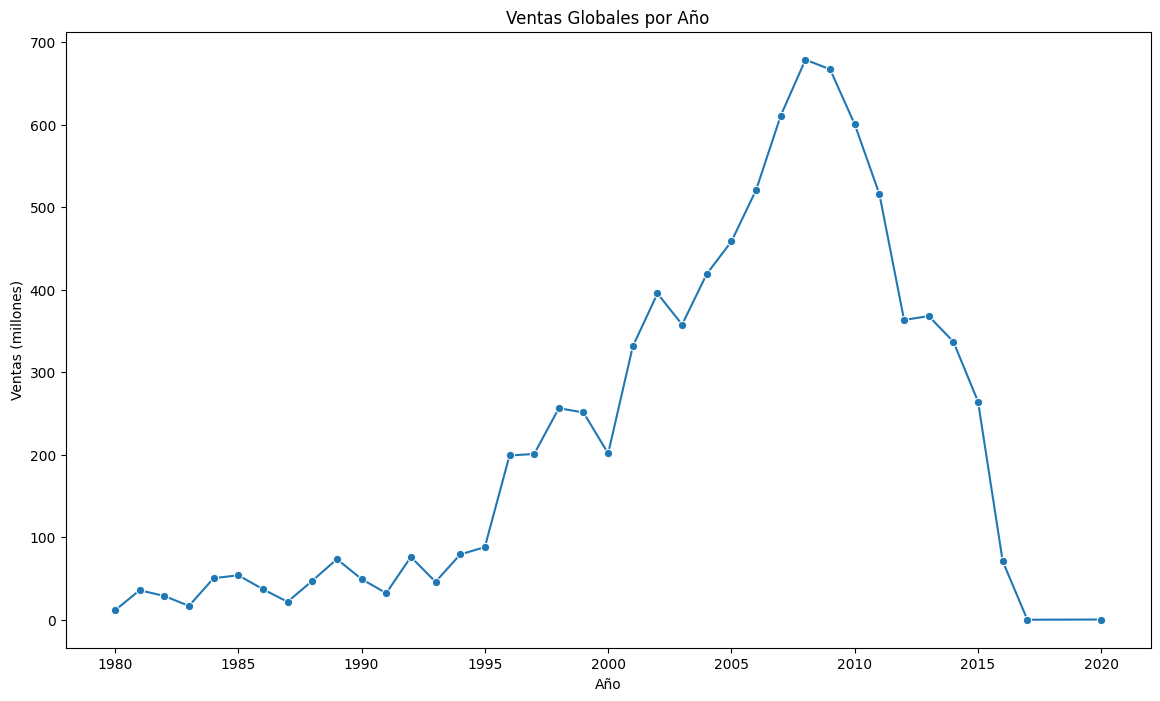

In [18]:
import seaborn as sns
import matplotlib.pyplot as plt

# agrandamos un poco mas la figura
plt.figure(figsize=(14, 8))  # ancho, alto en pulgadas

sns.lineplot(x=ventas_por_year.index, 
             y=ventas_por_year.values,
             marker='o')

plt.xlabel("Año")
plt.ylabel("Ventas (millones)")
plt.title("Ventas Globales por Año")
plt.show()

Tambien podemos comparar las regiones entre si.

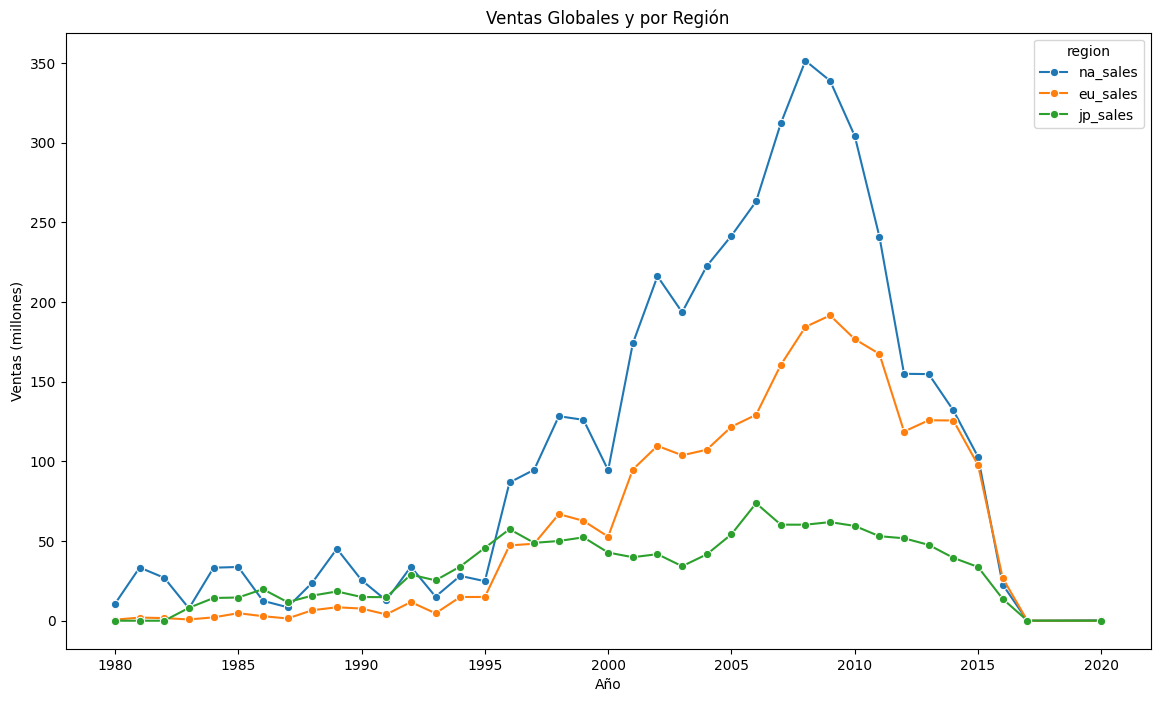

In [19]:
# agrupamos por year
ventas_por_anio = data.groupby('year')[[
    'na_sales',
    'eu_sales',
    'jp_sales',
]].sum().reset_index() # esto hace que la columna year no sea mas el indice

# convertimos en formato largo
ventas_long = ventas_por_anio.melt(  # el metodo melt transorma el df en un df largo 
    id_vars='year',
    var_name='region',
    value_name='sales'
)

# figure en fomrato panoramico
plt.figure(figsize=(14, 8))

# y ahora hacemos el plot
sns.lineplot(
    data=ventas_long,
    x='year',
    y='sales',
    hue='region',
    marker='o'
)

plt.title("Ventas Globales y por Región")
plt.xlabel("Año")
plt.ylabel("Ventas (millones)")
plt.show()

## 2. La Guerra de las Consolas (Ciclo de Vida)
Las consolas no duran para siempre. Tienen un auge, una meseta y una caída cuando sale la siguiente generación.

Tarea: Selecciona 3 plataformas icónicas (por ejemplo: PS2, Wii, X360) y grafica su evolución de ventas año por año en un mismo gráfico.

Insight buscado: Observa cuánto tiempo suele durar el "reinado" de una consola antes de ser reemplazada.

Lo que haremos sera agrupar por consola sumar sus ventas totales, y vizualizremos las tres mas vendidas.

In [24]:
ventas_por_plataforma = data.groupby('platform')['global_sales'].sum() # agrupamos por plataforma 
ventas_por_plataforma = ventas_por_plataforma.sort_values(ascending=False)
ventas_por_plataforma.head(5)

platform
PS2     1233.46
X360     968.32
PS3      949.34
Wii      909.81
DS       818.96
Name: global_sales, dtype: float64

Seleccionaremos estas tres plataformas, y ahora tambien agruparemos por year y sumaremos para finalemente mostrar el resultado.

In [ ]:
ventas_por_plataforma_year = data.groupby(['platform','year'])['global_sales'].sum() # agrupamos por year y plataforma
ventas_por_plataforma_year = ventas_por_plataforma_year.reset_index() # sacamos los valores del index para que sea mas facil de graficar con seaborn
ventas_por_plataforma_year = ventas_por_plataforma_year.sort_values(by='year',ascending=False)

ventas_por_plataforma_year.head(), ventas_por_plataforma_year.tail()

(    platform  year  global_sales
 37        DS  2020          0.29
 178      PSV  2017          0.02
 159      PS4  2017          0.03
 17       3DS  2016          6.60
 177      PSV  2016          3.40,
    platform  year  global_sales
 3      2600  1983          5.83
 79      NES  1983         10.96
 2      2600  1982         28.86
 1      2600  1981         35.77
 0      2600  1980         11.38)

In [32]:
top5 = (
    data.groupby('platform')['global_sales']
    .sum()
    .nlargest(5)
    .index
)

ventas_top5 = ventas_por_plataforma_year[
    ventas_por_plataforma_year['platform'].isin(top5)
]
ventas_top5.head()

,platform,year,global_sales
37,DS,2020,0.29
154,PS3,2016,2.59
227,X360,2016,0.83
210,Wii,2015,1.55
153,PS3,2015,18.22


Ahora hagamos el grafico

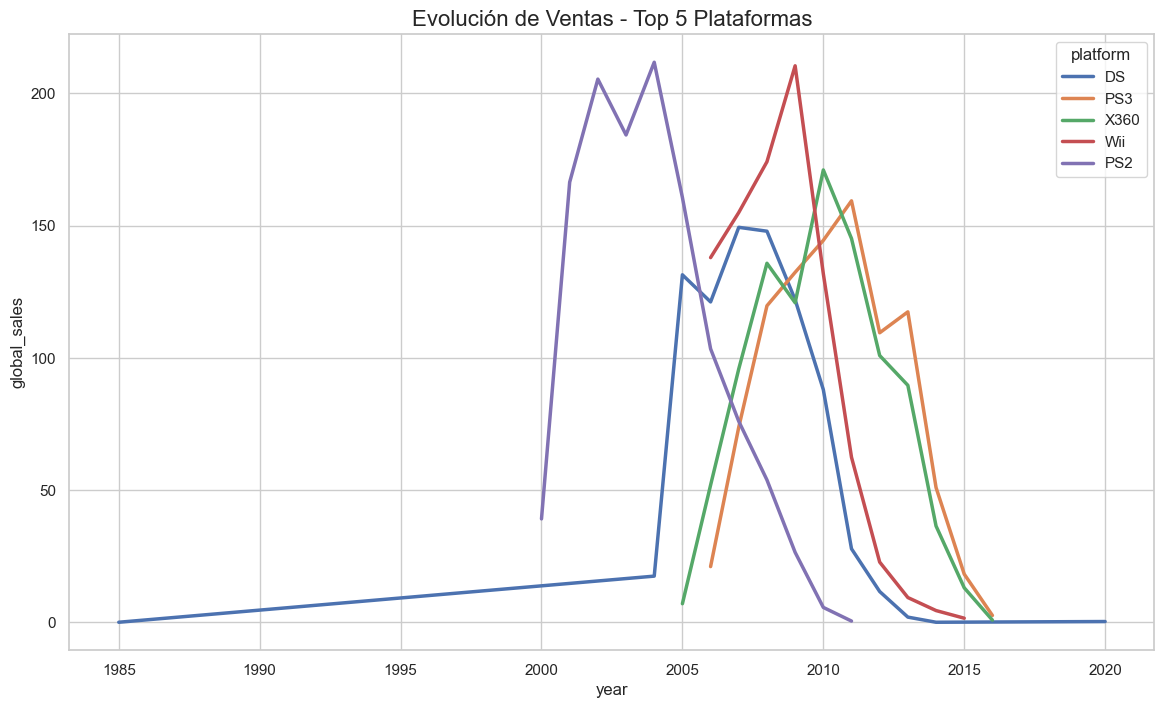

In [34]:
sns.set_theme(style="whitegrid")

plt.figure(figsize=(14,8))

sns.lineplot(
    data=ventas_top5,
    x='year',
    y='global_sales',
    hue='platform',
    linewidth=2.5
)

plt.title("Evolución de Ventas - Top 5 Plataformas", fontsize=16)
plt.show()


## 3. Evolución de los Géneros
¿El género "Action" siempre fue el líder o hubo una época donde mandaban otros?

Tarea: Compara las ventas de los géneros Platform, Action y Shooter a lo largo de las décadas.

para esto haremos algo muy similar al grafico de arriba pero en vez de agrupar por year agruparemos por genero

In [35]:
ventas_por_genre_year = data.groupby(['genre','year'])['global_sales'].sum() # agrupamos por year y plataforma
ventas_por_genre_year = ventas_por_genre_year.reset_index() # sacamos los valores del index para que sea mas facil de graficar con seaborn
ventas_por_genre_year = ventas_por_genre_year.sort_values(by='year',ascending=False)

ventas_por_genre_year.head(), ventas_por_genre_year.tail()

(            genre  year  global_sales
 325    Simulation  2020          0.29
 258  Role-Playing  2017          0.04
 37         Action  2017          0.01
 362        Sports  2016         14.60
 294       Shooter  2016         18.22,
         genre  year  global_sales
 259   Shooter  1980          7.07
 66   Fighting  1980          0.77
 326    Sports  1980          0.49
 95       Misc  1980          2.71
 0      Action  1980          0.34)

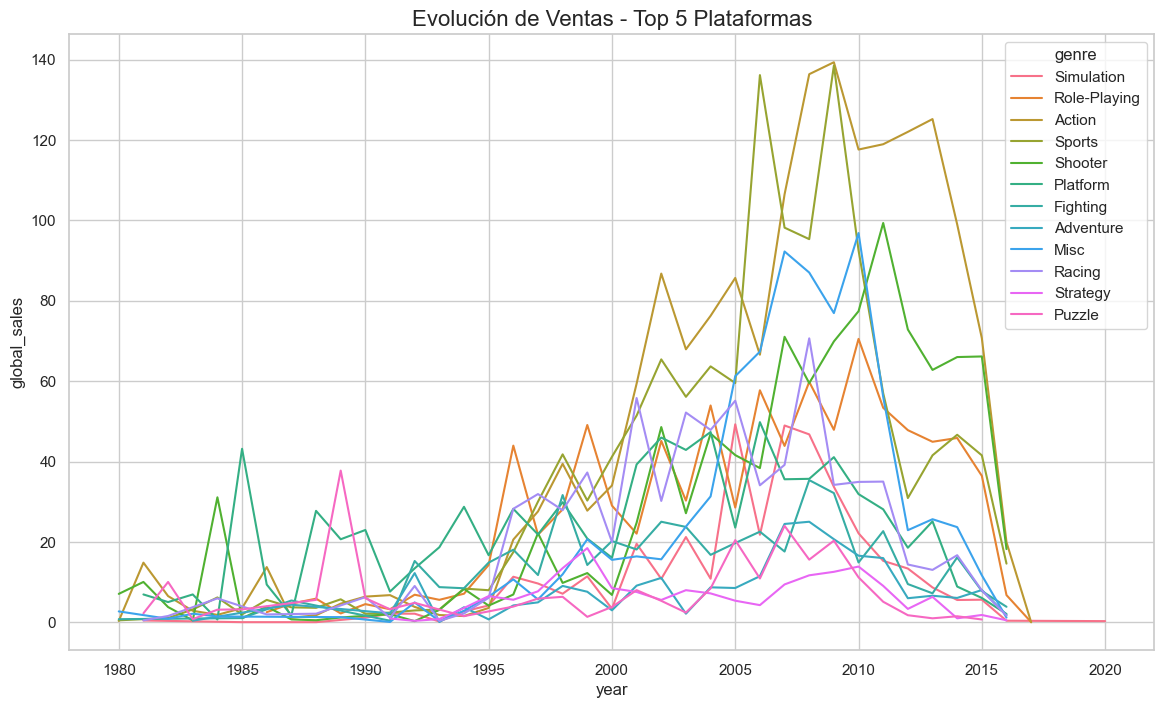

In [36]:
sns.set_theme(style="whitegrid")

plt.figure(figsize=(14,8))

sns.lineplot(
    data=ventas_por_genre_year,
    x='year',
    y='global_sales',
    hue='genre',
    linewidth=1.5,
)

plt.title("Evolución de Ventas - Top 5 Plataformas", fontsize=16)
plt.show()

Probemos con una forma mas ordenada.

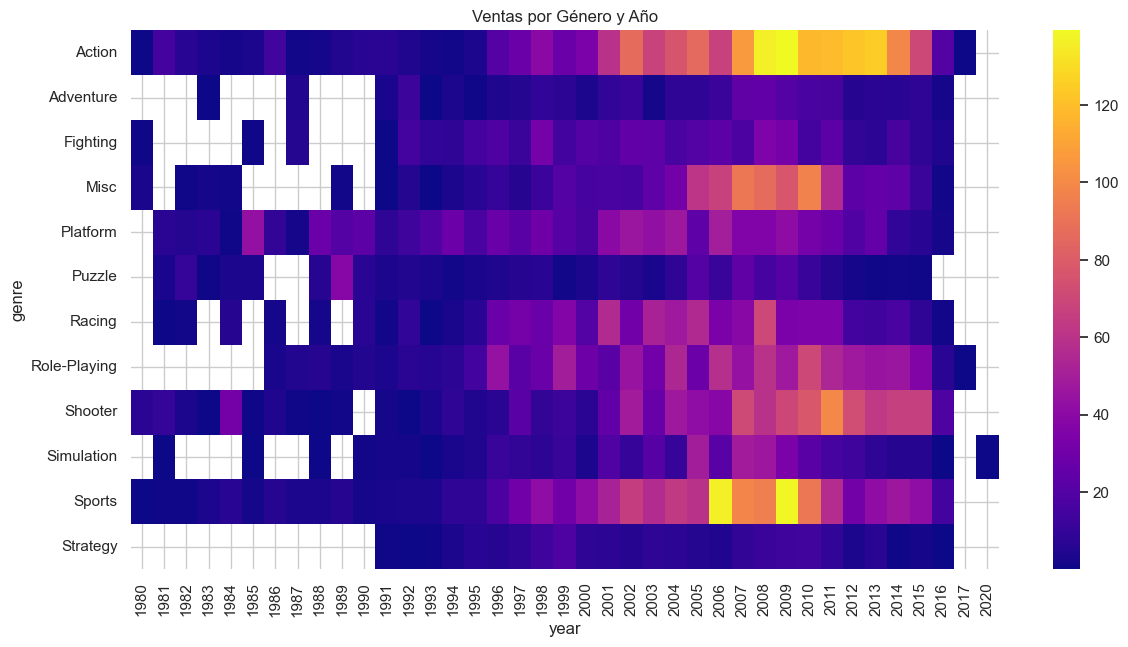

In [38]:
tabla = (
    data.groupby(['genre','year'])['global_sales']
    .sum()
    .unstack()
)

plt.figure(figsize=(14,7))
sns.heatmap(tabla, cmap="plasma")
plt.title("Ventas por Género y Año")
plt.show()